<a href="https://colab.research.google.com/github/ankita6876/AURUM-Net/blob/main/AURUM_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AURUM-Net: Regime-Gated Uncertainty-Aware Gold Price Forecasting

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("Gold Price.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df.head()
df.tail()
df.info()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3104 entries, 2014-01-01 to 2026-01-02
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3104 non-null   int64  
 1   Open    3104 non-null   int64  
 2   High    3104 non-null   int64  
 3   Low     3104 non-null   int64  
 4   Volume  3104 non-null   int64  
 5   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 169.8 KB


In [152]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


In [153]:
print(df.columns)


Index(['Price', 'Open', 'High', 'Low', 'Volume', 'Chg%'], dtype='object')


In [154]:
df.reset_index(inplace=True)
df.rename(columns={'index': 'Date'}, inplace=True)


In [155]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True) # Set 'Date' as index after cleaning and sorting

In [156]:
print(df.index.min())
print(df.index.max())

2014-01-01 00:00:00
2026-01-02 00:00:00


In [157]:
# Rename for financial convention
df.rename(columns={'Price': 'Close'}, inplace=True)

# Convert Chg% to float (if not already)
df['Chg%'] = df['Chg%'].astype(float)

# This line was creating an artificial index, causing a date mismatch.
# Removed: df.index = pd.date_range(start='2000-01-01', periods=len(df), freq='D')

df.head()

,Close,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


#Feature Engineering (Regime-Sensitive)

In [158]:
# Log returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Volatility (rolling)
df['Volatility'] = df['Log_Return'].rolling(14).std()

# Technical indicators
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_30'] = df['Close'].rolling(30).mean()

# Price range pressure
df['HL_Range'] = df['High'] - df['Low']
df['OC_Change'] = df['Open'] - df['Close']

df.dropna(inplace=True)


In [159]:
from sklearn.mixture import GaussianMixture

regime_features = df[['Log_Return', 'Volatility']].dropna()

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_regime_labels = gmm.fit_predict(regime_features)

# Store GMM labels directly into df, aligning by index
df.loc[regime_features.index, 'GMM_Regime_Labels'] = gmm_regime_labels
# Fill NaNs that occur outside of regime_features.index (e.g., due to initial dropna) with -1, to be removed later.
df['GMM_Regime_Labels'] = df['GMM_Regime_Labels'].fillna(-1).astype(int)

probs = gmm.predict_proba(regime_features)

df.loc[regime_features.index, 'regime_low_vol'] = probs[:, 0]
df.loc[regime_features.index, 'regime_mid_vol'] = probs[:, 1]
df.loc[regime_features.index, 'regime_high_vol'] = probs[:, 2]

# VOLATILITY-AWARE TARGET

In [160]:
# Log returns
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Rolling volatility (20-day window)
df['Volatility'] = df['Return'].rolling(window=20).std()

df.dropna(inplace=True)

#Market Regime Detection (NOVEL)

In [161]:
from sklearn.cluster import KMeans

vol = df[['Volatility']]

# Market regime now uses 3 GMM components, not binary volatility threshold
# Ensure 'GMM_Regime_Labels' exists and is correctly populated from previous cell
df['Regime'] = df['GMM_Regime_Labels'] # Use the GMM labels (0, 1, 2, or -1 for initial NaNs)

# Label regimes (optional, update if necessary for visualization)
# The -1 will be dropped by subsequent dropna operations
df['Regime_Label'] = df['Regime'].map({0: 'Regime 0', 1: 'Regime 1', 2: 'Regime 2', -1: 'Unknown'})

In [162]:
# Create the primary target (future Close price)
df['Target_Close'] = df['Close'].shift(-1)
# Create future volatility and regime targets
df['Target_Volatility'] = df['Volatility'].shift(-1)
df['Target_Regime'] = df['Regime'].shift(-1)

# Drop any rows where features or the new target are NaN
df.dropna(inplace=True)

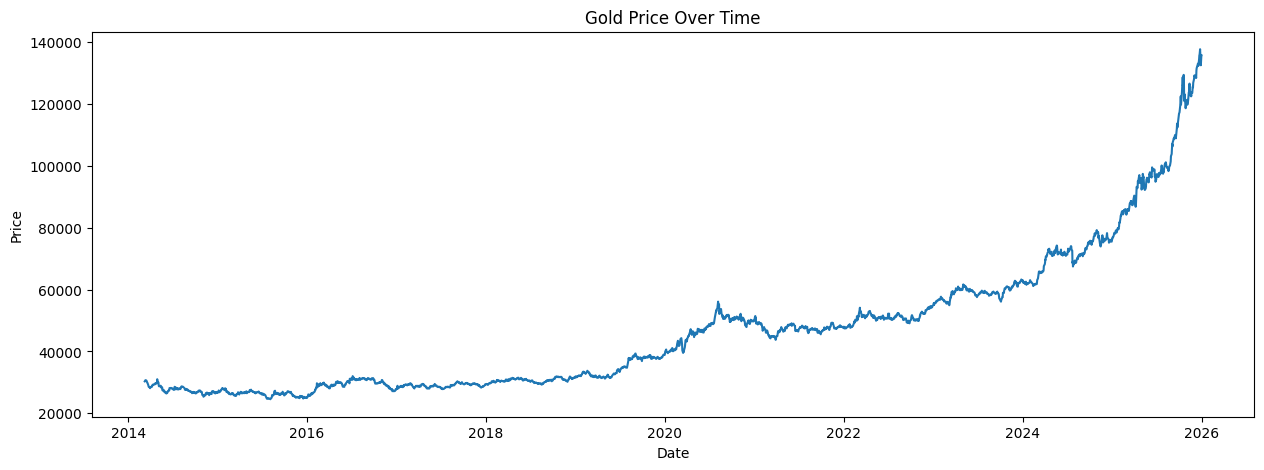

In [163]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['Close'])
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

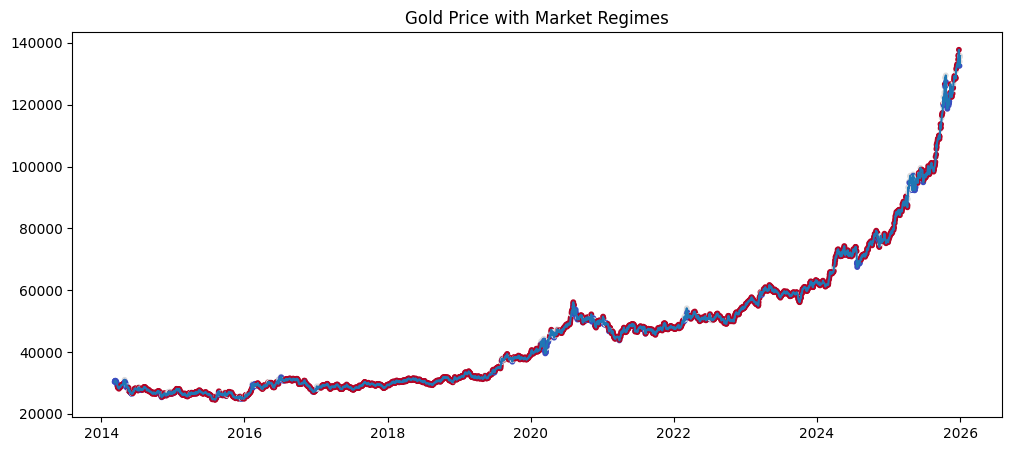

In [164]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'], label='Gold Price')
plt.scatter(df.index, df['Close'], c=df['Regime'], cmap='coolwarm', s=10)
plt.title("Gold Price with Market Regimes")
plt.show()




# Scaling + Sequence Creation



In [165]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import train_test_split # Import train_test_split
from tensorflow.keras.utils import to_categorical # NEW: Import to_categorical
import tensorflow as tf # Import TensorFlow

features = ['Close', 'Open', 'High', 'Low', 'Volume', 'Volatility', 'Regime']

# Define the target features
target_feature_price = 'Target_Close'
target_feature_volatility = 'Target_Volatility'
target_feature_regime = 'Target_Regime'

# Create separate scalers for features (X) and targets (y)
scaler_X = MinMaxScaler()
scaled_X = scaler_X.fit_transform(df[features])

scaler_y_price = MinMaxScaler()
scaled_y_price = scaler_y_price.fit_transform(df[[target_feature_price]])

scaler_y_volatility = MinMaxScaler()
scaled_y_volatility = scaler_y_volatility.fit_transform(df[[target_feature_volatility]])

# NEW: For regime, we will use integer labels directly from df['Target_Regime']
# and then one-hot encode them. No scaler needed for regime labels.
y_regime_labels_raw = df[target_feature_regime].values.flatten() # Get raw labels as 1D array

# Modified create_multi_resolution_windows function to take X and Y separately
def create_multi_resolution_windows(X_data, y_price_data, y_vol_data, y_reg_data_labels_raw, short=7, mid=30, long=120):
    Xs, Xm, Xl, y_price_seq, y_vol_seq, y_reg_seq_labels_raw = [], [], [], [], [], []

    # Iterate through the data to create windows and corresponding targets
    # The target for a window ending at `i-1` is at `i`.
    # So the loop should go from `long` up to `len(X_data)`
    for i in range(long, len(X_data)):
        Xs.append(X_data[i-short:i]) # Window for short term features
        Xm.append(X_data[i-mid:i])   # Window for mid term features
        Xl.append(X_data[i-long:i])  # Window for long term features

        # Targets corresponding to the end of the window (i.e., predicting for index 'i')
        y_price_seq.append(y_price_data[i])
        y_vol_seq.append(y_vol_data[i])
        y_reg_seq_labels_raw.append(y_reg_data_labels_raw[i]) # Append raw integer labels

    return (
        np.array(Xs),
        np.array(Xm),
        np.array(Xl),
        np.array(y_price_seq),
        np.array(y_vol_seq),
        np.array(y_reg_seq_labels_raw) # Return raw integer labels
    )

# Call the modified function to get all sequences
Xs, Xm, Xl, y_price, y_vol, y_reg_labels_int = create_multi_resolution_windows(
    scaled_X, scaled_y_price, scaled_y_volatility, y_regime_labels_raw, # Pass 1D array
    short=7, mid=30, long=120
)

# NEW: One-hot encode the regime labels
# Assuming 3 classes (0, 1, 2) based on GMM_Regime_Labels
y_reg = to_categorical(y_reg_labels_int, num_classes=3)

# Perform train-test split for each resolution of features and all targets
# Use one split index for all data to maintain chronological order
split_index = int(len(Xs) * 0.8) # Assuming all X and y sequences have the same length

# Convert all numpy arrays to tf.Tensor with float32 dtype explicitly
X_train_s, X_val_s = tf.convert_to_tensor(Xs[:split_index], dtype=tf.float32), tf.convert_to_tensor(Xs[split_index:], dtype=tf.float32)
X_train_m, X_val_m = tf.convert_to_tensor(Xm[:split_index], dtype=tf.float32), tf.convert_to_tensor(Xm[split_index:], dtype=tf.float32)
X_train_l, X_val_l = tf.convert_to_tensor(Xl[:split_index], dtype=tf.float32), tf.convert_to_tensor(Xl[split_index:], dtype=tf.float32)

y_price_train, y_price_val = tf.convert_to_tensor(y_price[:split_index], dtype=tf.float32), tf.convert_to_tensor(y_price[split_index:], dtype=tf.float32)
y_vol_train, y_vol_val = tf.convert_to_tensor(y_vol[:split_index], dtype=tf.float32), tf.convert_to_tensor(y_vol[split_index:], dtype=tf.float32)
y_reg_train, y_reg_val = tf.convert_to_tensor(y_reg[:split_index], dtype=tf.float32), tf.convert_to_tensor(y_reg[split_index:], dtype=tf.float32)

In [166]:
# ==========================
# BASELINE 1: Vanilla LSTM
# ==========================
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

input_base = Input(shape=(X_train_m.shape[1], X_train_m.shape[2]))

x = LSTM(64)(input_base)
x = Dense(32, activation='relu')(x)
output = Dense(1, name='price')(x)

baseline_lstm = Model(inputs=input_base, outputs=output)

baseline_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

baseline_lstm.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 30, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

In [167]:
history_baseline = baseline_lstm.fit(
    X_train_m,
    y_price_train,
    validation_data=(X_val_m, y_price_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        )
    ]
)


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0027 - mae: 0.0340 - val_loss: 0.0084 - val_mae: 0.0635
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 4.6397e-05 - mae: 0.0051 - val_loss: 0.0070 - val_mae: 0.0550
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.5571e-05 - mae: 0.0051 - val_loss: 0.0072 - val_mae: 0.0566
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.2376e-05 - mae: 0.0049 - val_loss: 0.0077 - val_mae: 0.0600
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.0979e-05 - mae: 0.0048 - val_loss: 0.0076 - val_mae: 0.0598
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.9145e-05 - mae: 0.0047 - val_loss: 0.0074 - val_mae: 0.0587
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.6884e-05 - mae: 0.0045 - val_loss: 0.0067 - val_mae: 0.0545
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3.5531e-05 - mae: 0.0044 - val_loss: 0.0065 - val_mae: 0.0534
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━

In [168]:
pred_base = baseline_lstm.predict(X_val_m)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Convert TensorFlow tensors to NumPy arrays (pred_base is already a numpy array)
y_price_val_np = y_price_val.numpy()
pred_base_np = pred_base

mae_base = mean_absolute_error(y_price_val_np, pred_base_np)
rmse_base = np.sqrt(mean_squared_error(y_price_val_np, pred_base_np))

print("Vanilla LSTM MAE:", mae_base)
print("Vanilla LSTM RMSE:", rmse_base)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Vanilla LSTM MAE: 0.04317009821534157
Vanilla LSTM RMSE: 0.06982846013772112


In [169]:
# ===============================
# BASELINE 2: Attention LSTM
# ===============================

from tensorflow.keras.layers import Attention

input_att = Input(shape=(X_train_m.shape[1], X_train_m.shape[2]))

enc = LSTM(64, return_sequences=True)(input_att)
att = Attention()([enc, enc])
att = att[:, -1, :]

dense = Dense(32, activation='relu')(att)
out = Dense(1)(dense)

attention_lstm = Model(inputs=input_att, outputs=out)

attention_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

attention_lstm.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 30, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_15 (LSTM)      │ (None, 30, 64)    │     18,432 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_9         │ (None, 30, 64)    │          0 │ lstm_15[0][0],    │
│ (Attention)         │                   │            │ lstm_15[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_17         │ (None, 64)        │          0 │ attention_9[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ get_item_17[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         33 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

In [170]:
history_att = attention_lstm.fit(
    X_train_m,
    y_price_train,
    validation_data=(X_val_m, y_price_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        )
    ]
)


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0083 - mae: 0.0629 - val_loss: 0.0112 - val_mae: 0.0713
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.1525e-04 - mae: 0.0082 - val_loss: 0.0088 - val_mae: 0.0623
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.0429e-04 - mae: 0.0078 - val_loss: 0.0069 - val_mae: 0.0541
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.0150e-04 - mae: 0.0077 - val_loss: 0.0060 - val_mae: 0.0502
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 9.7769e-05 - mae: 0.0075 - val_loss: 0.0056 - val_mae: 0.0485
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 9.8885e-05 - mae: 0.0076 - val_loss: 0.0053 - val_mae: 0.0466
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.0106e-04 - mae: 0.0077 - val_loss: 0.0055 - val_mae: 0.0480
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.0356e-04 - mae: 0.0078 - val_loss: 0.0056 - val_mae: 0.0484
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━

In [171]:
pred_att = attention_lstm.predict(X_val_m)

mae_att = mean_absolute_error(y_price_val.numpy(), pred_att)
rmse_att = np.sqrt(mean_squared_error(y_price_val.numpy(), pred_att))

print("Attention LSTM MAE:", mae_att)
print("Attention LSTM RMSE:", rmse_att)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Attention LSTM MAE: 0.046611275523900986
Attention LSTM RMSE: 0.0725990541994211


In [172]:
print(df.columns)


Index(['Close', 'Open', 'High', 'Low', 'Volume', 'Chg%', 'Log_Return',
       'Volatility', 'MA_10', 'MA_30', 'HL_Range', 'OC_Change',
       'GMM_Regime_Labels', 'regime_low_vol', 'regime_mid_vol',
       'regime_high_vol', 'Return', 'Regime', 'Regime_Label', 'Target_Close',
       'Target_Volatility', 'Target_Regime'],
      dtype='object')


In [173]:
print(type(df))
print(df.head())
print(df.columns)


<class 'pandas.core.frame.DataFrame'>
            Close   Open   High    Low  Volume  Chg%  Log_Return  Volatility  \
Date                                                                           
2014-03-10  30327  30253  30350  30145   13500  0.07    0.000660    0.021787   
2014-03-11  30421  30301  30515  30166   23170  0.31    0.003095    0.021755   
2014-03-12  30627  30468  30690  30468   19020  0.68    0.006749    0.021790   
2014-03-13  30697  30677  30735  30492   15380  0.23    0.002283    0.021790   
2014-03-14  30719  30730  30849  30610   19040  0.07    0.000716    0.021755   

              MA_10         MA_30  ...  GMM_Regime_Labels  regime_low_vol  \
Date                               ...                                      
2014-03-10  30983.3  30290.366667  ...                  0        0.993402   
2014-03-11  30928.2  30316.800000  ...                  0        0.991576   
2014-03-12  30909.9  30343.200000  ...                  0        0.988446   
2014-03-13  3089

In [174]:
# =====================================
# BASELINE 3 — ARIMA (Fair Comparison)
# =====================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the SAME target used in deep learning

full_series = df['Target_Close'].values.reshape(-1)
print(np.min(full_series), np.max(full_series))

train_size = len(y_price_train)

train_series = full_series[:train_size]
val_series   = full_series[train_size:train_size + len(y_price_val)]

# Fit ARIMA
arima_model = ARIMA(train_series, order=(5,1,0))
arima_fit = arima_model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=len(val_series))

# Evaluate
mae_arima = mean_absolute_error(val_series, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(val_series, arima_forecast))

print("ARIMA MAE :", mae_arima)
print("ARIMA RMSE:", rmse_arima)


24545.0 137789.0
ARIMA MAE : 11940.52020713051
ARIMA RMSE: 16582.205054740585


In [175]:
print("\n====== MODEL COMPARISON ======")
print(f"Vanilla LSTM MAE: {mae_base:.4f}")
print(f"Attention LSTM MAE: {mae_att:.4f}")
print(f"AURUM-Net MAE: {price_mae:.4f}")
print(f"ARIMA MAE: {mae_arima:.4f}")



====== MODEL COMPARISON ======
Vanilla LSTM MAE: 0.0432
Attention LSTM MAE: 0.0466
AURUM-Net MAE: 0.0257
ARIMA MAE: 11940.5202


# Multi-head Attention LSTM (Regime-Gated Attention)

In [176]:
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Attention
from tensorflow.keras.models import Model
import keras.ops as ops # Import keras.ops

input_s = Input(shape=(X_train_s.shape[1], X_train_s.shape[2]))
input_m = Input(shape=(X_train_m.shape[1], X_train_m.shape[2]))
input_l = Input(shape=(X_train_l.shape[1], X_train_l.shape[2]))

enc_s = LSTM(32, return_sequences=True)(input_s)
enc_m = LSTM(32, return_sequences=True)(input_m)
enc_l = LSTM(32, return_sequences=True)(input_l)

from tensorflow.keras.layers import Multiply, Softmax

# Regime gate (learned from long-term context)
regime_gate = Dense(3, activation='softmax', name='regime_gate')(enc_l[:, -1, :])

# Create attention heads
attn_s = Attention()([enc_s, enc_s])[:, -1, :]
attn_m = Attention()([enc_m, enc_m])[:, -1, :]
attn_l = enc_l[:, -1, :]

# Stack attention heads using keras.ops
attn_stack = ops.stack([attn_s, attn_m, attn_l], axis=1)

# Apply regime gate using keras.ops
gate_expanded = ops.expand_dims(regime_gate, axis=-1)
gated_context = ops.sum(attn_stack * gate_expanded, axis=1)


shared = Dense(64, activation='relu')(gated_context)

# Predict price distribution instead of point estimate
from tensorflow.keras.layers import Dense, Lambda

base = Dense(1, name='price_base')(shared)

delta1 = Dense(1, activation='softplus', name='delta1')(shared)
delta2 = Dense(1, activation='softplus', name='delta2')(shared)

price_q10 = Lambda(
    lambda x: x[0] - x[1] - x[2],
    name='price_q10'
)([base, delta1, delta2])

price_q50 = Lambda(
    lambda x: x[0],
    name='price_q50'
)([base])

price_q90 = Lambda(
    lambda x: x[0] + x[1] + x[2],
    name='price_q90'
)([base, delta1, delta2])



vol_out = Dense(1, name='volatility')(shared)
regime_out = Dense(3, activation='softmax', name='regime')(shared)

model = Model(
    inputs=[input_s, input_m, input_l],
    outputs=[price_q10, price_q50, price_q90, vol_out, regime_out]
)

def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

def interval_width_loss(y_true, y_pred):
    # Encourage wider, calibrated intervals
    return tf.reduce_mean(tf.abs(y_pred))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'price_q10': quantile_loss(0.1),
        'price_q50': quantile_loss(0.5),
        'price_q90': quantile_loss(0.9),
        'volatility': 'mse',
        'regime': 'categorical_crossentropy'
    },
    loss_weights={
        'price_q10': 0.45,
        'price_q50': 0.45,
        'price_q90': 0.45,
        'volatility': 0.03,
        'regime': 0.02
    },
    metrics={
        'price_q50': ['mae'],
        'regime': ['accuracy']
    }
)


model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 7, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 30, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 120, 7)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_16 (LSTM)      │ (None, 7, 32)     │      5,120 │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_17 (LSTM)      │ (None, 30, 32)    │      5,120 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_18 (LSTM)      │ (None, 120, 32)   │      5,120 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_10        │ (None, 7, 32)     │          0 │ lstm_16[0][0],    │
│ (Attention)         │                   │            │ lstm_16[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_11        │ (None, 30, 32)    │          0 │ lstm_17[0][0],    │
│ (Attention)         │                   │            │ lstm_17[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_18         │ (None, 32)        │          0 │ lstm_18[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_19         │ (None, 32)        │          0 │ attention_10[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_20         │ (None, 32)        │          0 │ attention_11[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_21         │ (None, 32)        │          0 │ lstm_18[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regime_gate (Dense) │ (None, 3)         │         99 │ get_item_18[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 3, 32)     │          0 │ get_item_19[0][0… │
│                     │                   │            │ get_item_20[0][0… │
│                     │                   │            │ get_item_21[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_4       │ (None, 3, 1)      │          0 │ regime_gate[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 3, 32)     │          0 │ stack_4[0][0],    │
│ (Multiply)          │                   │            │ expand_dims_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_4 (Sum)         │ (None, 32)        │          0 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      2,112 │ sum_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 18,026 (70.41 KB)

 Trainable params: 18,026 (70.41 KB)

 Non-trainable params: 0 (0.00 B)

In [177]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_price_q50_mae',
        patience=12,
        restore_best_weights=True,
        mode='min' # Added this line to specify that MAE should be minimized
    )
]

model.fit(
    [X_train_s, X_train_m, X_train_l],
    {
        'price_q10': y_price_train,
        'price_q50': y_price_train,
        'price_q90': y_price_train,
        'volatility': y_vol_train,
        'regime': y_reg_train
    },
    validation_data=(
        [X_val_s, X_val_m, X_val_l],
        {
            'price_q10': y_price_val,
            'price_q50': y_price_val,
            'price_q90': y_price_val,
            'volatility': y_vol_val,
            'regime': y_reg_val
        }
    ),
    epochs=120,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.1334 - price_q10_loss: 0.1185 - price_q50_loss: 0.0163 - price_q50_mae: 0.0325 - price_q90_loss: 0.1178 - regime_accuracy: 0.8815 - regime_loss: 0.9138 - volatility_loss: 0.0492 - val_loss: 0.0349 - val_price_q10_loss: 0.0168 - val_price_q50_loss: 0.0177 - val_price_q50_mae: 0.0316 - val_price_q90_loss: 0.0122 - val_regime_accuracy: 0.8109 - val_regime_loss: 0.7079 - val_volatility_loss: 0.0456
Epoch 2/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0213 - price_q10_loss: 0.0094 - price_q50_loss: 0.0071 - price_q50_mae: 0.0142 - price_q90_loss: 0.0095 - regime_accuracy: 0.8815 - regime_loss: 0.4487 - volatility_loss: 0.0202 - val_loss: 0.0308 - val_price_q10_loss: 0.0065 - val_price_q50_loss: 0.0185 - val_price_q50_mae: 0.0337 - val_price_q90_loss: 0.0177 - val_regime_accuracy: 0.8109 - val_regime_loss: 0.6355 - val_volatility_loss: 0.0459
Epoch 3/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0138 - price_q10_

In [178]:
pred_q10, pred_q50, pred_q90, pred_vol, pred_reg = model.predict(
    [X_val_s, X_val_m, X_val_l]
)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


In [179]:
# Convert tensors to numpy
y_price_val_np = y_price_val.numpy()
y_vol_val_np   = y_vol_val.numpy()
y_reg_val_np   = y_reg_val.numpy()

pred_price_np = pred_q50 # Corrected: 'pred_price' was not defined, should be pred_q50
pred_vol_np   = pred_vol
pred_reg_np   = pred_reg

In [180]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

price_mae = mean_absolute_error(y_price_val_np, pred_price_np)
price_rmse = np.sqrt(mean_squared_error(y_price_val_np, pred_price_np))

print(f"Price MAE  : {price_mae:.4f}")
print(f"Price RMSE : {price_rmse:.4f}")


Price MAE  : 0.0170
Price RMSE : 0.0268


In [181]:
vol_mae = mean_absolute_error(y_vol_val_np, pred_vol_np)
print(f"Volatility MAE : {vol_mae:.4f}")


Volatility MAE : 0.0802


In [182]:
from sklearn.metrics import accuracy_score

true_regime = np.argmax(y_reg_val_np, axis=1)
pred_regime = np.argmax(pred_reg_np, axis=1)

regime_acc = accuracy_score(true_regime, pred_regime)
print(f"Regime Classification Accuracy: {regime_acc:.4f}")


Regime Classification Accuracy: 0.8109


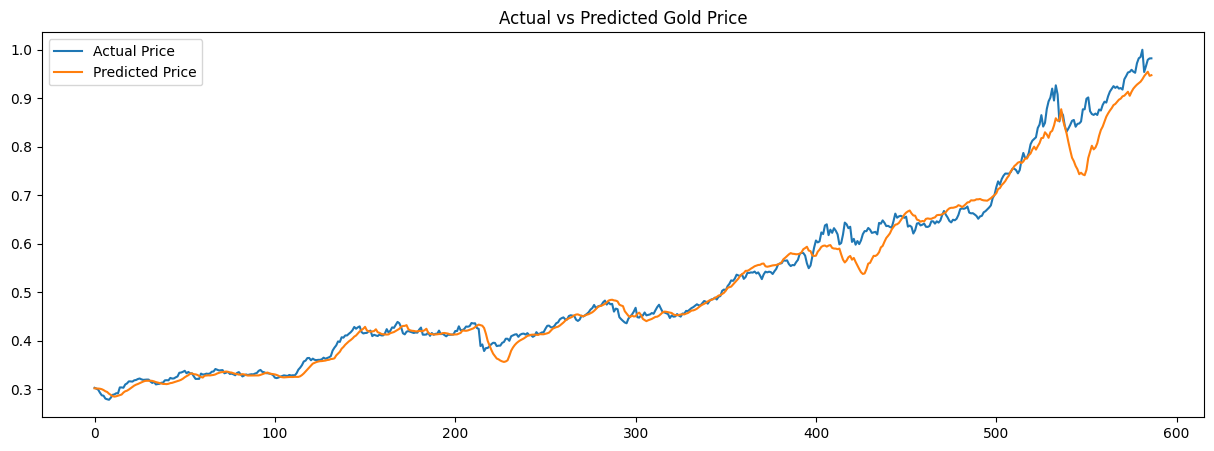

In [183]:
plt.figure(figsize=(15,5))
plt.plot(y_price_val, label='Actual Price')
plt.plot(pred_price_np, label='Predicted Price')
plt.title('Actual vs Predicted Gold Price')
plt.legend()
plt.show()

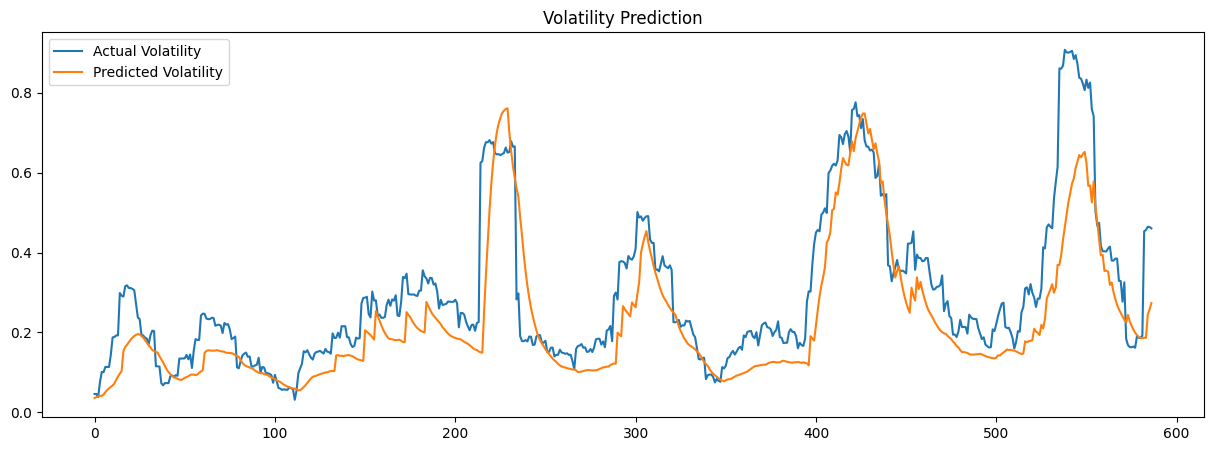

In [184]:
plt.figure(figsize=(15,5))
plt.plot(y_vol_val, label='Actual Volatility')
plt.plot(pred_vol, label='Predicted Volatility')
plt.title('Volatility Prediction')
plt.legend()
plt.show()


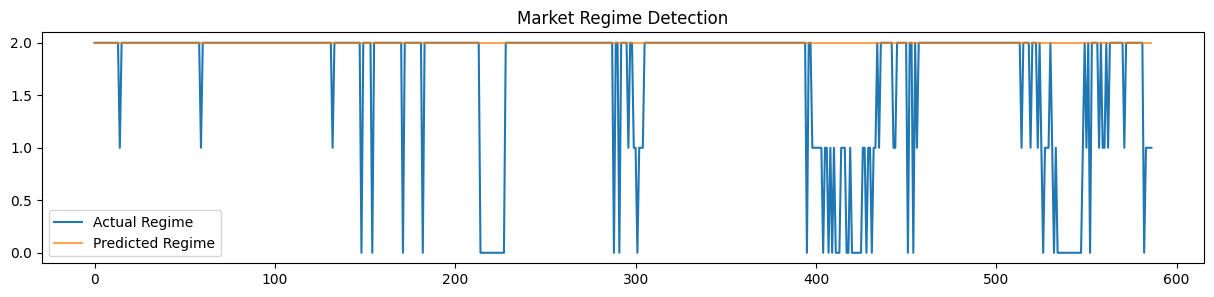

In [185]:
plt.figure(figsize=(15,3))
plt.plot(true_regime, label='Actual Regime')
plt.plot(pred_regime, alpha=0.7, label='Predicted Regime')
plt.title('Market Regime Detection')
plt.legend()
plt.show()


/tmp/ipython-input-2451864574.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


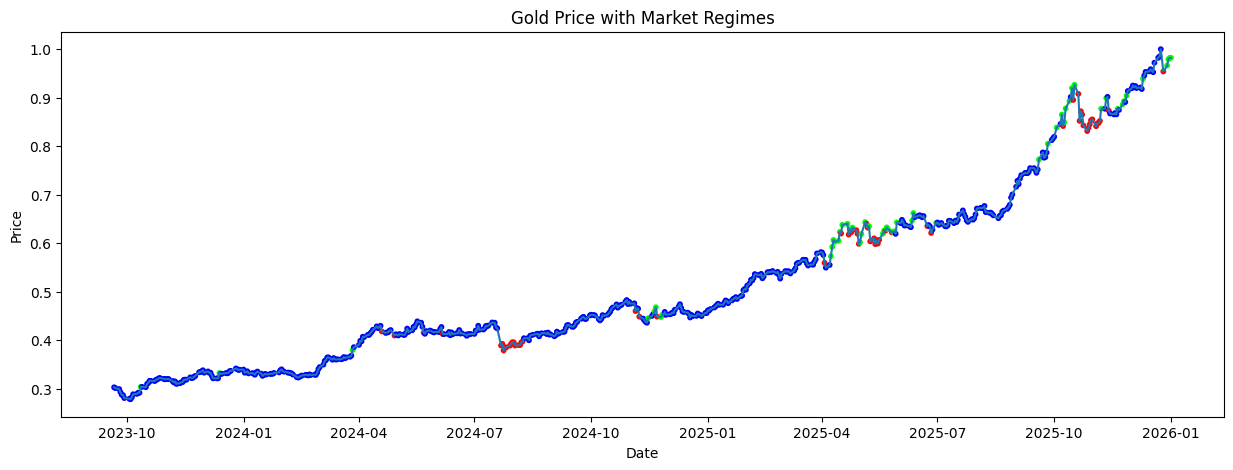

In [186]:
val_dates = df.index[-len(y_price_val):]

plt.figure(figsize=(15,5))
plt.plot(val_dates, y_price_val, label='Price')

plt.scatter(
    val_dates,
    y_price_val,
    c=y_reg_val,
    cmap='coolwarm',
    s=10,
    label='Regime'
)

plt.title('Gold Price with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [187]:
# Coverage probability
coverage = np.mean(
    (y_price_val_np >= pred_q10) & (y_price_val_np <= pred_q90)
)

print(f"80% Interval Coverage: {coverage:.3f}")

80% Interval Coverage: 0.535


In [188]:
# Conformal calibration (CQR)
residuals = np.maximum(
    pred_q10 - y_price_val_np,
    y_price_val_np - pred_q90
)

q_hat = np.quantile(residuals, 0.8)

# Calibrated intervals
pred_q10_cal = pred_q10 - q_hat
pred_q90_cal = pred_q90 + q_hat

# New coverage
coverage_cal = np.mean(
    (y_price_val_np >= pred_q10_cal) &
    (y_price_val_np <= pred_q90_cal)
)

print("Calibrated 80% Coverage:", coverage_cal)


Calibrated 80% Coverage: 0.7989778534923339


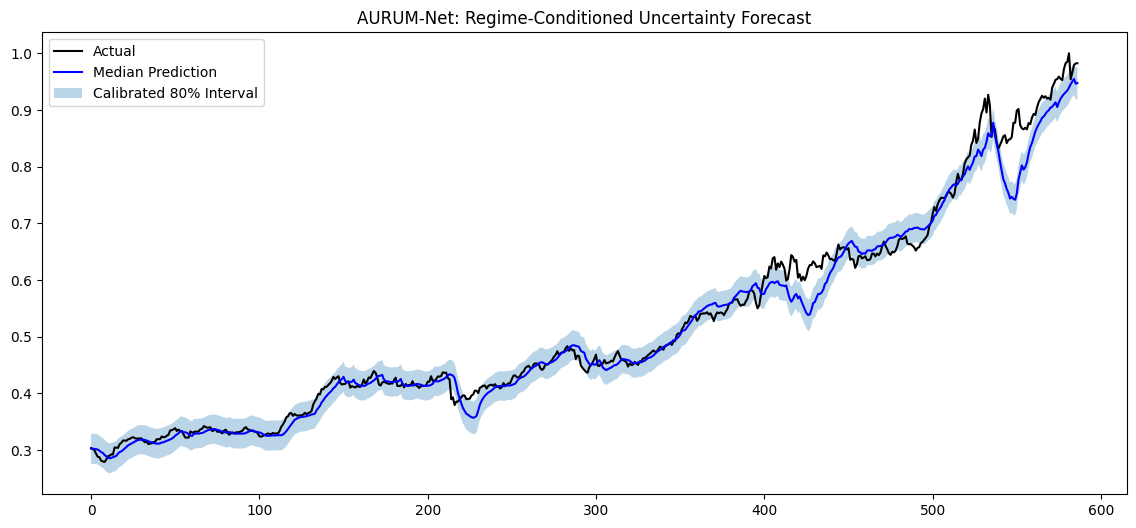

In [189]:
plt.figure(figsize=(14,6))
plt.plot(y_price_val_np, label='Actual', color='black')
plt.plot(pred_q50, label='Median Prediction', color='blue')
plt.fill_between(
    range(len(pred_q50)),
    pred_q10_cal.flatten(),
    pred_q90_cal.flatten(),
    alpha=0.3,
    label='Calibrated 80% Interval'
)

plt.legend()
plt.title("AURUM-Net: Regime-Conditioned Uncertainty Forecast")
plt.show()

In [190]:
val_dates = df.index[-len(y_price_val_np):]

recent_mask = val_dates >= pd.Timestamp('2022-01-01')

recent_mae = mean_absolute_error(
    y_price_val_np[recent_mask],
    pred_price_np[recent_mask]
)

print("Recent Period MAE:", recent_mae)


Recent Period MAE: 0.016966942697763443


# ATTENTION-BASED LSTM

# QUANTILE REGRESSION

In [191]:
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q*e, (q-1)*e))
    return loss


In [194]:
#model.compile(
    optimizer='adam',
    loss={
        'subtract_1': quantile_loss(0.1),
        'dense_2': quantile_loss(0.5),
        'add_1': quantile_loss(0.9),
        'volatility': 'mse',
        'regime': 'categorical_crossentropy'
    },
    loss_weights={
        'subtract_1': 0.3,
        'dense_2': 0.3,
        'add_1': 0.3,
        'volatility': 0.05,
        'regime': 0.05
    }

)

IndentationError: unexpected indent (ipython-input-2180992905.py, line 2)

In [195]:
# Interval coverage
lower = pred_q10
upper = pred_q90
true = y_price_val_np

picp = np.mean((true >= lower) & (true <= upper))
mpiw = np.mean(upper - lower)

print(f"PICP (coverage): {picp:.3f}")
print(f"MPIW (interval width): {mpiw:.3f}")


PICP (coverage): 0.535
MPIW (interval width): 0.022


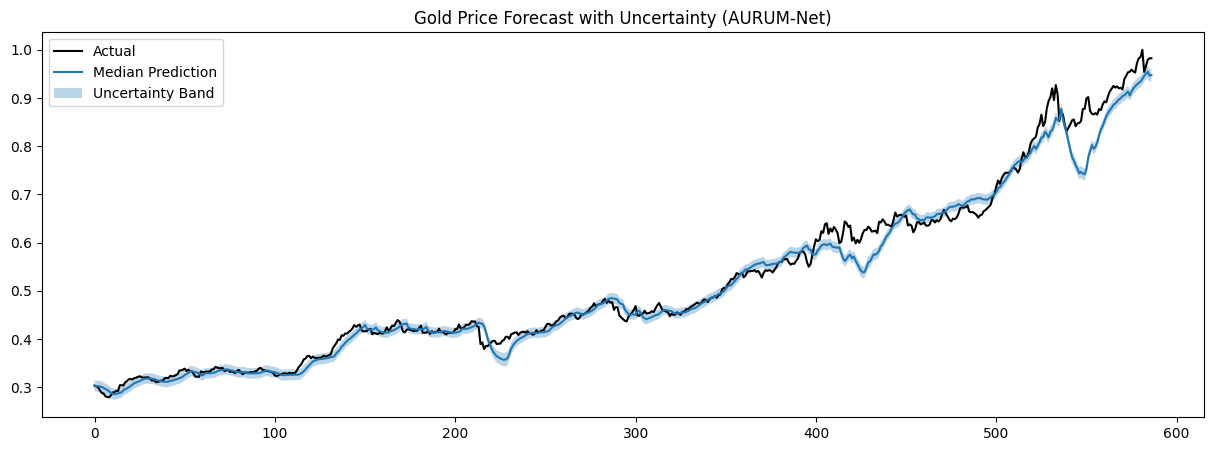

In [196]:
plt.figure(figsize=(15,5))
plt.plot(true, label='Actual', color='black')
plt.plot(pred_q50, label='Median Prediction')
plt.fill_between(
    range(len(true)),
    pred_q10.flatten(),
    pred_q90.flatten(),
    alpha=0.3,
    label='Uncertainty Band'
)
plt.legend()
plt.title('Gold Price Forecast with Uncertainty (AURUM-Net)')
plt.show()


In [197]:
direction_true = np.sign(y_price_val_np[1:] - y_price_val_np[:-1])
direction_pred = np.sign(pred_q50[1:] - pred_q50[:-1])

directional_accuracy = np.mean(direction_true == direction_pred)
print("Directional Accuracy:", directional_accuracy)

Directional Accuracy: 0.5494880546075085


In [198]:
coverage_80 = np.mean(
    (y_price_val_np >= pred_q10) & (y_price_val_np <= pred_q90)
)
print("80% Prediction Interval Coverage:", coverage_80)


80% Prediction Interval Coverage: 0.534923339011925


In [200]:
for r in range(3):
    # pred_regime is already a 1D array of argmax from LpjQePWC9916
    idx = (pred_regime == r)
    if idx.sum() > 20:
        print(f"Regime {r} RMSE:",
              np.sqrt(mean_squared_error(y_price_val_np[idx], pred_q50[idx])))

Regime 2 RMSE: 0.026827633043398667
